In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio

from scipy.interpolate import interp1d
from scipy.interpolate import griddata
from scipy.signal import savgol_filter

In [2]:
params = {'legend.fontsize': 'large',
         'axes.labelsize': 'large',
         'axes.titlesize':'large',
         'xtick.labelsize':'large',
         'ytick.labelsize':'large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
min_nobs = 2
maskbits = sorted([1, 8, 9, 11, 12, 13])

photom_columns = ['MORPHTYPE', 'EBV', 'FLUX_G', 'FLUX_R', 'FLUX_Z', 'FLUX_W1', 'FLUX_W2', 'FIBERFLUX_Z', 'SHAPE_R', 'SERSIC']

cat = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_targets/dr9.0/combined/dr9_lrg_south_1.0.0_basic.fits'))
photom = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_targets/dr9.0/combined/dr9_lrg_south_1.0.0_photom.fits', columns=photom_columns))
cat = hstack([cat, photom], join_type='exact')
print(len(cat))
south = cat.copy()

cat = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_targets/dr9.0/combined/dr9_lrg_north_1.0.0_basic.fits'))
photom = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_targets/dr9.0/combined/dr9_lrg_north_1.0.0_photom.fits', columns=photom_columns))
cat = hstack([cat, photom], join_type='exact')
print(len(cat))
north = cat.copy()

cat = vstack([south, north])
print(len(cat))

cat.rename_column('MORPHTYPE', 'TYPE')

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    cat['gmag'] = 22.5 - 2.5*np.log10(cat['FLUX_G']) - 3.214 * cat['EBV']
    cat['rmag'] = 22.5 - 2.5*np.log10(cat['FLUX_R']) - 2.165 * cat['EBV']
    cat['zmag'] = 22.5 - 2.5*np.log10(cat['FLUX_Z']) - 1.211 * cat['EBV']
    cat['w1mag'] = 22.5 - 2.5*np.log10(cat['FLUX_W1']) - 0.184 * cat['EBV']
    cat['zfibermag'] = 22.5 - 2.5*np.log10(cat['FIBERFLUX_Z']) - 1.211 * cat['EBV']
    
mask_clean = np.ones(len(cat), dtype=bool)
for bit in maskbits:
    mask_clean &= (cat['MASKBITS'] & 2**bit)==0
print(np.sum(~mask_clean)/len(mask_clean))
cat = cat[mask_clean]
print(len(cat))

mask = (cat['NOBS_G']>=min_nobs) & (cat['NOBS_R']>=min_nobs) & (cat['NOBS_Z']>=min_nobs)
cat = cat[mask]
print(len(cat))

mask_south = cat['PHOTSYS']=='S'
mask_north = cat['PHOTSYS']=='N'

# Near edge of the fiber-flux cut
mask = np.full(len(cat), False)
mask |= mask_north & (cat['zfibermag']>21.60)
mask |= mask_south & (cat['zfibermag']>21.59)
cat = cat[mask]

9144035
3194955
12338990
0.10460434768161737
11048278
10579981


----------
# REX

In [4]:
data = np.load('/Users/rongpu/git/desi-targets/lrg_xcorr/magnification/data/rex.npz')
print(data.files)
ratio_interp = interp1d(data['shape_r'], data['ratio'], bounds_error=False, fill_value='extrapolate', kind='quadratic')
f_factor_interp = interp1d(data['shape_r'], data['f_factor'], bounds_error=False, fill_value='extrapolate', kind='quadratic')

['shape_r', 'ratio', 'f_factor']


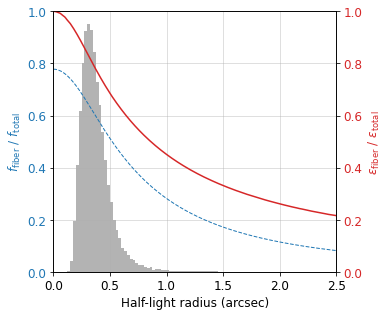

In [41]:
r_grid = np.arange(0., 10+0.01, 0.01)

fig, ax1 = plt.subplots(figsize=(5.5, 4.5))
ax1.plot(r_grid, ratio_interp(r_grid), lw=1, color='C0', ls='--')
mask = cat['TYPE']=='REX'
ax1.hist(cat['SHAPE_R'][mask], 100, range=(0, 2.5), density=False, weights=np.full(np.sum(mask), 1.4e-4), color='0.7')
ax1.axis([0, 2.5, 0., 1])
ax1.grid(alpha=0.5)
ax1.set_xlabel('Half-light radius (arcsec)')
ax1.set_ylabel('$f_\mathrm{fiber}$ / $f_\mathrm{total}$', color='C0')
ax1.tick_params(axis='y', labelcolor='C0')
ax2 = ax1.twinx()
ax2.plot(r_grid, f_factor_interp(r_grid), color='C3')
ax2.set_ylabel('$\epsilon_\mathrm{fiber}$ / $\epsilon_\mathrm{total}$', color='C3')
ax2.tick_params(axis='y', labelcolor='C3')
ax2.axis([0, 2.5, 0., 1])
plt.tight_layout()
plt.savefig('figures/rex_fiberflux.pdf')
plt.show()

---------
# DEV

In [5]:
rmin, rmax, qmin, qmax = 0., 10., 1., 10.
r_grid = np.arange(rmin, rmax+0.01, 0.01)
q_grid = np.arange(qmin, qmax+0.01, 0.01)
q_mesh, r_mesh = np.meshgrid(q_grid, r_grid)

In [7]:
data_dev_ratio = np.load('/Users/rongpu/git/desi-targets/lrg_xcorr/magnification/data/dev_fiber_ratio.npz')

def ratio_interp_dev(r, q):
    q = np.clip(q, 1.03, 9.98)
    r = np.clip(r, 0., 9.99)
    return griddata(np.array([data_dev_ratio['shape_r'], data_dev_ratio['q']]).T, data_dev_ratio['ratio'], (r, q), method='cubic')

img_ratio = ratio_interp_dev(r_mesh, q_mesh).T

In [13]:
data_dev_factor = np.load('/Users/rongpu/git/desi-targets/lrg_xcorr/magnification/data/dev_fiber_factor.npz')
print(data.files)
r_mesh_flat, q_mesh_flat, f_factor_mesh_smooth_flat = data_dev_factor['shape_r'], data_dev_factor['q'], data_dev_factor['f_factor']

def f_factor_interp(r, q):

    q = np.clip(q, 1.03, 9.98)
    r = np.clip(r, 0., 9.99)

    f = griddata(np.array([r_mesh_flat, q_mesh_flat]).T, f_factor_mesh_smooth_flat, (r, q), method='cubic')
    f = np.clip(f, 0., 1.)

    return f

img_factor = f_factor_interp(r_mesh, q_mesh).T
img_factor[np.isnan(img_ratio)] = np.nan

['shape_r', 'ratio', 'f_factor']


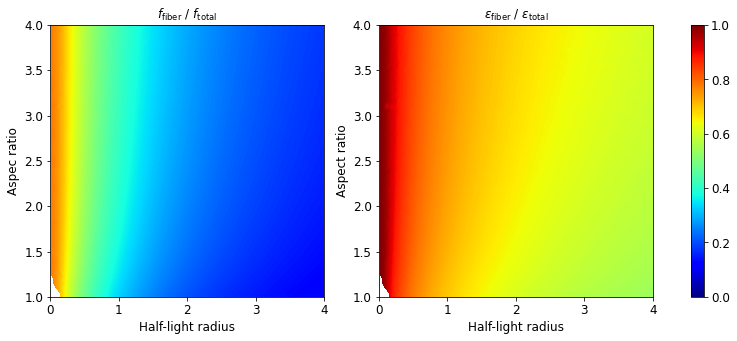

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5))

im = axes[0].imshow(img_ratio, vmin=0, vmax=1, origin='lower', cmap='jet', extent=(r_mesh.min(), r_mesh.max(), q_mesh.min(), q_mesh.max()), aspect='auto')
axes[0].set_xlabel('Half-light radius')
axes[0].set_ylabel('Aspec ratio')
axes[0].set_title('$f_\mathrm{fiber}$ / $f_\mathrm{total}$')
axes[0].axis([0, 4, 1., 4.])

axes[1].imshow(img_factor, vmin=0, vmax=1, origin='lower', cmap='jet', extent=(r_mesh.min(), r_mesh.max(), q_mesh.min(), q_mesh.max()), aspect='auto')
axes[1].set_xlabel('Half-light radius')
axes[1].set_ylabel('Aspect ratio')
axes[1].set_title('$\epsilon_\mathrm{fiber}$ / $\epsilon_\mathrm{total}$')
axes[1].axis([0, 4, 1., 4.])

plt.colorbar(im, ax=axes)
plt.savefig('figures/dev_fiberflux.pdf')
plt.show()